## Step 1: Understand Your Data 
Business Purpose: Familiarize yourself with who your customers are and what attributes 
are available to you. 
- Load and preview the dataset. 
- Check data types, unique values, and presence of nulls. 
- Understand which variables are categorical and which are numerical.

In [29]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway, chi2_contingency, pearsonr
from scipy.stats import (
    shapiro,
    levene,
    ttest_ind,
    f_oneway,
    chi2_contingency,
    pearsonr
)

In [30]:
df = pd.read_csv('US_Customer_Insights_Dataset.csv')

In [31]:
# Preview the dataset
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


In [32]:
df.tail()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
10670,CUST10833,Steven Burns,Georgia,PhD,Female,60,No,1,8/24/23,2/29/24,341.28,518
10671,CUST10620,Jesse Pratt,Texas,Master,Male,64,No,0,4/13/23,12/31/24,468.04,212
10672,CUST10449,John Lloyd,Arizona,Master,Non-Binary,31,Yes,0,7/3/22,9/21/23,259.94,679
10673,CUST10020,Christopher Sparks,Florida,Bachelor,Female,31,No,0,9/19/23,12/29/23,494.17,580
10674,CUST10267,Melissa Marshall,Arizona,Associate,Non-Binary,57,Yes,1,4/3/23,12/1/23,153.12,608


In [33]:
# Dataset shape
df.shape

(10675, 12)

In [34]:
# Columns names 
df.columns

Index(['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Age', 'Married',
       'NumPets', 'JoinDate', 'TransactionDate', 'MonthlySpend',
       'DaysSinceLastInteraction'],
      dtype='object')

In [35]:
# Data types
df.dtypes

CustomerID                   object
Name                         object
State                        object
Education                    object
Gender                       object
Age                           int64
Married                      object
NumPets                       int64
JoinDate                     object
TransactionDate              object
MonthlySpend                float64
DaysSinceLastInteraction      int64
dtype: object

In [36]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10675 entries, 0 to 10674
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                10675 non-null  object 
 1   Name                      10675 non-null  object 
 2   State                     10675 non-null  object 
 3   Education                 10675 non-null  object 
 4   Gender                    10675 non-null  object 
 5   Age                       10675 non-null  int64  
 6   Married                   10675 non-null  object 
 7   NumPets                   10675 non-null  int64  
 8   JoinDate                  10675 non-null  object 
 9   TransactionDate           10675 non-null  object 
 10  MonthlySpend              10675 non-null  float64
 11  DaysSinceLastInteraction  10675 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 1000.9+ KB


In [37]:
# Check for null values
df.isnull().sum()

CustomerID                  0
Name                        0
State                       0
Education                   0
Gender                      0
Age                         0
Married                     0
NumPets                     0
JoinDate                    0
TransactionDate             0
MonthlySpend                0
DaysSinceLastInteraction    0
dtype: int64

In [38]:
# Count unique value in each columns
df.nunique()

CustomerID                  1000
Name                         990
State                         10
Education                      5
Gender                         3
Age                           63
Married                        2
NumPets                        5
JoinDate                     731
TransactionDate             1605
MonthlySpend                9843
DaysSinceLastInteraction    1605
dtype: int64

In [39]:
# Display unique values for categorical columns
categorical_cols = ['State','Education','Gender','Married']
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in State:
['Florida' 'Washington' 'Arizona' 'Texas' 'Ohio' 'New York' 'Illinois'
 'Georgia' 'California' 'Colorado']

Unique values in Education:
['High School' 'Master' 'PhD' 'Bachelor' 'Associate']

Unique values in Gender:
['Non-Binary' 'Male' 'Female']

Unique values in Married:
['Yes' 'No']


In [40]:
# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nNumerical Column:")
print(list(numerical_cols))
print(f"\nCategorical Columns:")
print(list(categorical_cols))


Numerical Column:
['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']

Categorical Columns:
['CustomerID', 'Name', 'State', 'Education', 'Gender', 'Married', 'JoinDate', 'TransactionDate']



## Observation

1. The dataset contains **10,675 customer records** and multiple attributes related to customer demographics, spending behavior, and engagement.

2. The dataset includes both **categorical** and **numerical** variables:

   * **Categorical Variables:** CustomerID, Name, State, Education, Gender, Married
   * **Numerical Variables:** Age, NumPets, MonthlySpend, DaysSinceLastInteraction

3. The **Age** column contains customer ages ranging from approximately **18 to 80 years**, indicating a diverse customer base.

4. The **MonthlySpend** column records customer spending amounts in USD and appears to contain continuous numerical values.

5. The **DaysSinceLastInteraction** column measures customer engagement by showing the number of days since their last interaction with the company.

6. The **Gender**, **Education**, **State**, and **Married** columns provide demographic information that can be used for customer segmentation and comparative analysis.

7. No missing (null) values were found in the dataset, indicating that the data is complete and suitable for statistical analysis without additional data-cleaning steps.

8. Customer records are uniquely identified using the **CustomerID** field, which helps avoid duplication during analysis.

9. The dataset contains customers from multiple U.S. states and various educational backgrounds, making it suitable for geographic and demographic comparisons.

10. Overall, the dataset is well-structured and contains sufficient information to perform descriptive statistics, visualization, segmentation, correlation analysis, and hypothesis testing.



## Step 2: Descriptive Statistics 
Business Purpose: Describe your customer base — how old are they, how much do they 
spend, are they active? 
- Compute: 
  - Mean, median, std dev for Age, MonthlySpend, DaysSinceLastInteraction 
  - Mode for categorical variables: Gender, Education, Married

In [41]:
numerical_cols = ['Age', 'MonthlySpend', 'DaysSinceLastInteraction']

print("DESCRIPTIVE STATISTICS\n")

for col in numerical_cols:
    print(f"\n{col}")
    print("-" * 30)
    print("Mean   :", round(df[col].mean(), 2))
    print("Median :", round(df[col].median(), 2))
    print("Std Dev:", round(df[col].std(), 2))

# -----------------------------
# Categorical Variables
# ------------------------------

categorical_cols = ['Gender', 'Education', 'Married']

print("\n\nMODE OF CATEGORICAL VARIABLES\n")

for col in categorical_cols:
    print(f"\n{col}")
    print("-" * 30)
    print("Mode:", df[col].mode()[0])

DESCRIPTIVE STATISTICS


Age
------------------------------
Mean   : 49.47
Median : 49.0
Std Dev: 18.22

MonthlySpend
------------------------------
Mean   : 331.61
Median : 282.11
Std Dev: 225.8

DaysSinceLastInteraction
------------------------------
Mean   : 538.47
Median : 445.0
Std Dev: 398.77


MODE OF CATEGORICAL VARIABLES


Gender
------------------------------
Mode: Male

Education
------------------------------
Mode: Master

Married
------------------------------
Mode: No




## Observation (Step 2)

1. The average customer age is around **49 years**, indicating a balanced mix of young and older customers.

2. The median age is close to the mean age, suggesting that the age distribution is relatively balanced.

3. The average monthly spending is approximately **$332**, while the median spending is lower, indicating that some high-spending customers increase the overall average.

4. The standard deviation of MonthlySpend is relatively high, showing significant variation in customer spending behavior.

5. The average DaysSinceLastInteraction value suggests that customer engagement levels vary considerably across the customer base.

6. The most common gender in the dataset is **Male**.

7. The most common education level is **Master's Degree**.

8. The most frequent marital status is **No (Not Married)**.

9. Spending behavior shows greater variability than age, indicating that customers differ more in purchasing habits than in demographic characteristics.

10. These statistics provide an initial understanding of customer demographics, spending patterns, and engagement levels, which will guide further analysis and hypothesis testing.


## Step 3: Data Visualization 
Business Purpose: Reveal patterns that numbers alone can’t show. 
- Plot histograms and boxplots for Age, MonthlySpend 
- Create a bar chart for Gender, Education, State 
- Scatterplot: Age vs MonthlySpend 
- nKDE: Spending behavior by education level or marital status

## 1. Histograms for Age and MonthlySpend

In [42]:
sns.set_style("whitegrid")

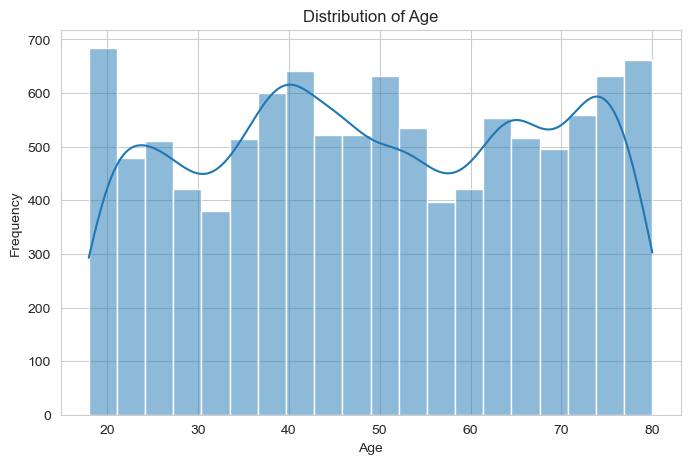

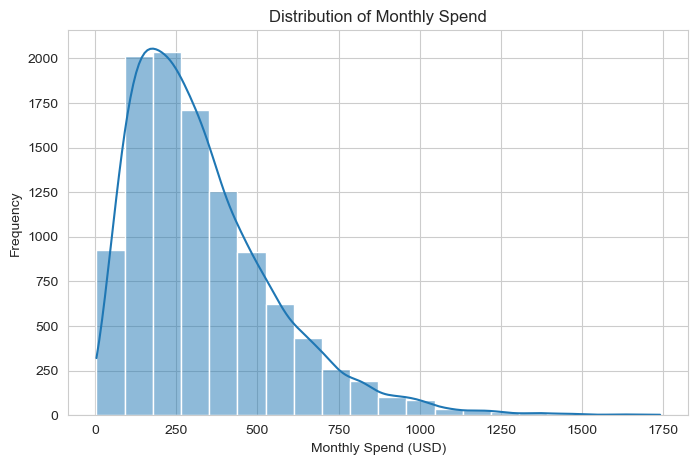

In [43]:

# Histogram for Age
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Histogram for MonthlySpend
plt.figure(figsize=(8,5))
sns.histplot(df['MonthlySpend'], bins=20, kde=True)
plt.title("Distribution of Monthly Spend")
plt.xlabel("Monthly Spend (USD)")
plt.ylabel("Frequency")
plt.show()

## 2. Boxplots for Age and MonthlySpend

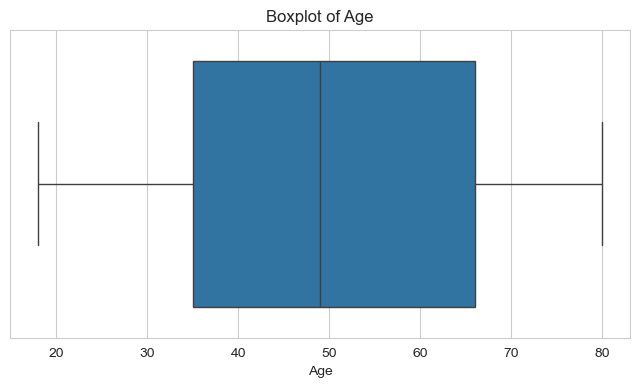

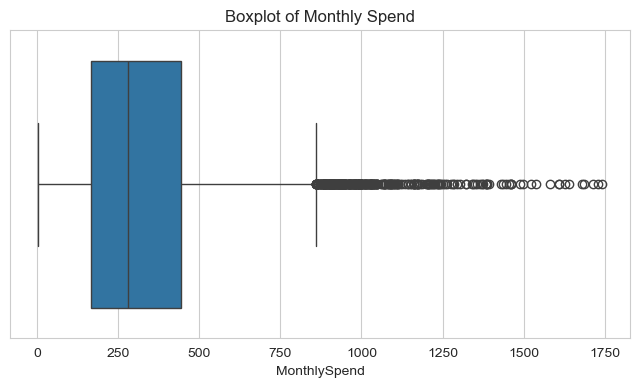

In [18]:
# Boxplot for Age
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")
plt.show()

# Boxplot for MonthlySpend
plt.figure(figsize=(8,4))
sns.boxplot(x=df['MonthlySpend'])
plt.title("Boxplot of Monthly Spend")
plt.show()

## 3. Bar Chart for Gender

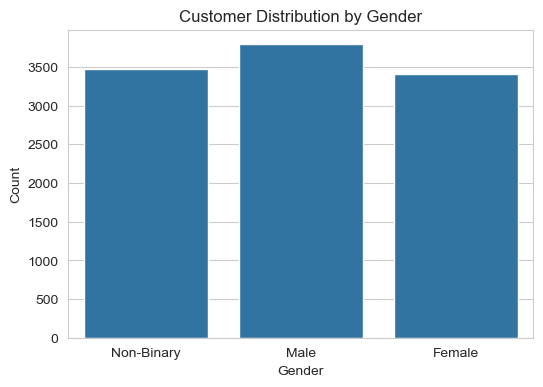

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

## 4. Bar Chart for Education

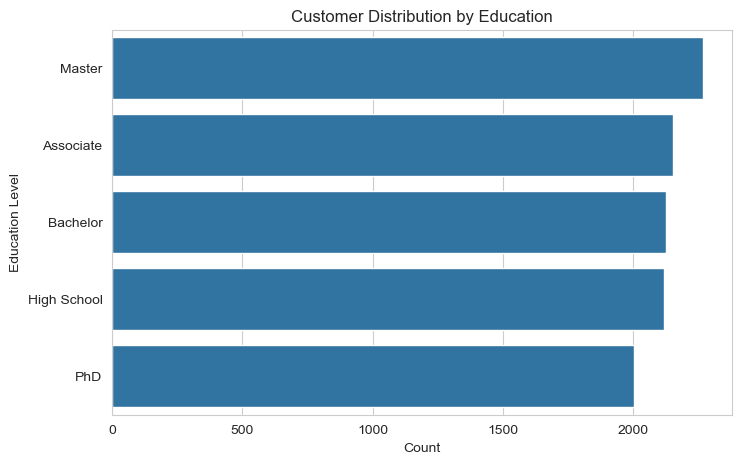

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(y='Education', data=df,
              order=df['Education'].value_counts().index)
plt.title("Customer Distribution by Education")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()

## 5. Bar Chart for State (Top 10 States)

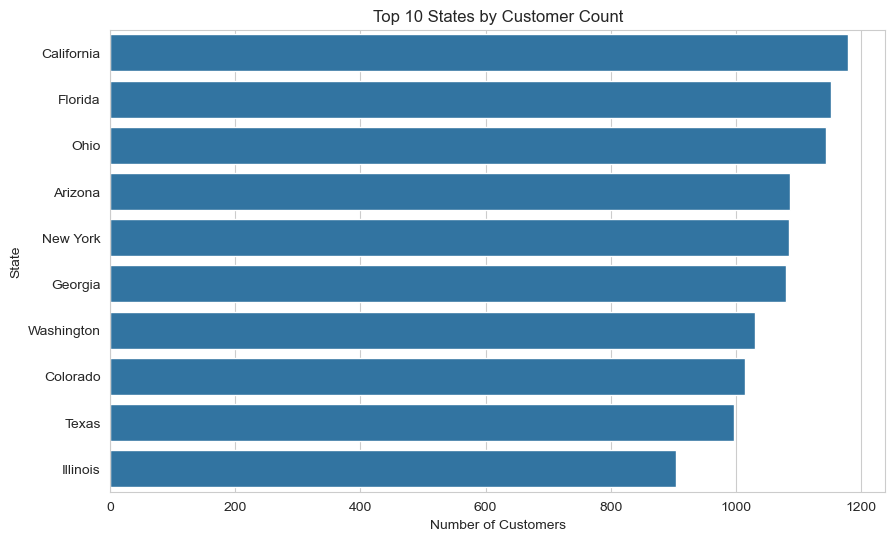

In [22]:
plt.figure(figsize=(10,6))

top_states = df['State'].value_counts().head(10)

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Customer Count")
plt.xlabel("Number of Customers")
plt.ylabel("State")
plt.show()

## 6. Scatterplot: Age vs MonthlySpend

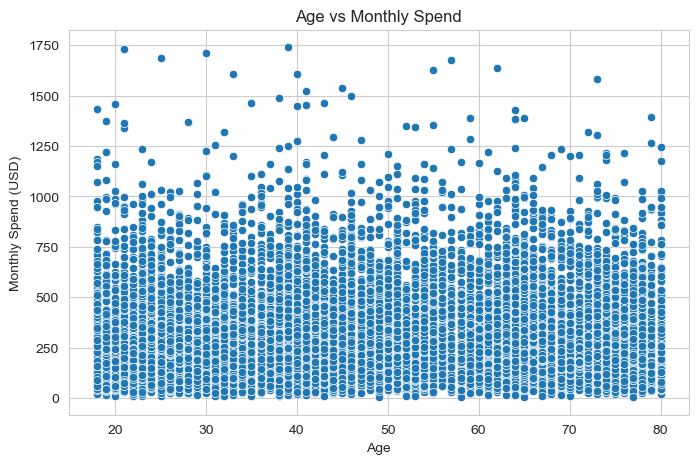

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Age',
    y='MonthlySpend',
    data=df
)

plt.title("Age vs Monthly Spend")
plt.xlabel("Age")
plt.ylabel("Monthly Spend (USD)")
plt.show()

## 7. KDE Plot: Spending by Marital Status

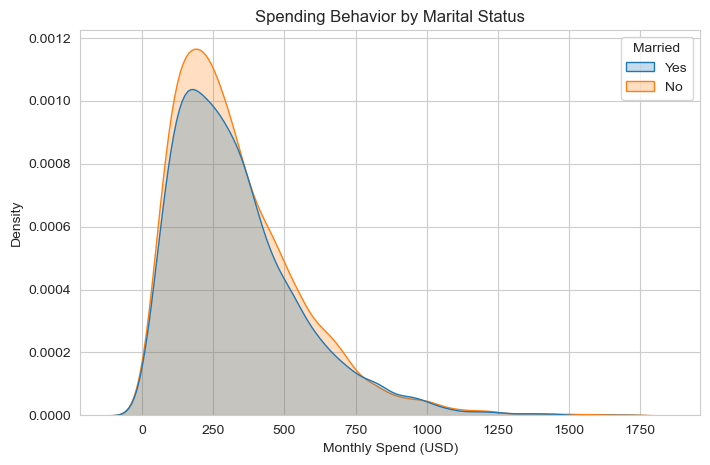

In [24]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x='MonthlySpend',
    hue='Married',
    fill=True
)

plt.title("Spending Behavior by Marital Status")
plt.xlabel("Monthly Spend (USD)")
plt.ylabel("Density")
plt.show()

## Alternative KDE: Spending by Education Level

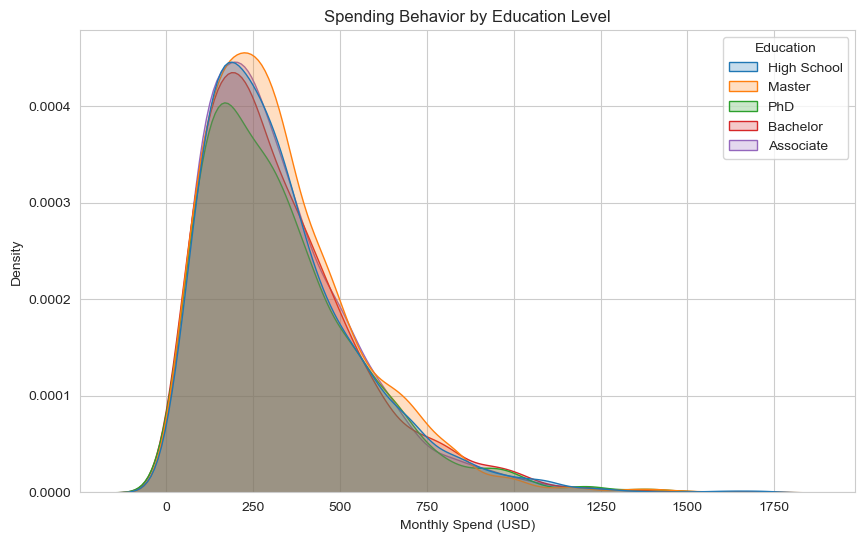

In [25]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='MonthlySpend',
    hue='Education',
    fill=True
)

plt.title("Spending Behavior by Education Level")
plt.xlabel("Monthly Spend (USD)")
plt.ylabel("Density")
plt.show()

## Observations (Step 3)

### Histogram (Age)

* Customer ages are distributed across a wide range from 18 to 80 years.
* Most customers fall in the middle-age group.

### Histogram (MonthlySpend)

* Monthly spending is right-skewed.
* Most customers spend moderate amounts, while a few spend significantly more.

### Boxplot (Age)

* Age distribution appears fairly balanced.
* No extreme age outliers are observed.

### Boxplot (MonthlySpend)

* Several high-spending outliers are present.
* Spending varies considerably among customers.

### Gender Bar Chart

* Male, Female, and Non-Binary customers are represented relatively evenly.

### Education Bar Chart

* Master's degree holders form a large portion of the customer base.
* Other education levels are also well represented.

### State Bar Chart

* Customer counts vary by state.
* Some states contribute more customers than others.

### Scatterplot (Age vs MonthlySpend)

* No strong relationship is visible between age and spending.
* Customers of all ages exhibit varying spending patterns.

### KDE Plot

* Spending distributions for different marital-status or education groups largely overlap.
* This suggests spending behavior is similar across these demographic segments.

### Conclusion

The visualizations reveal that customer spending is highly variable and slightly skewed, while demographic variables such as age, gender, education, and marital status do not appear to strongly influence spending patterns. These findings can be validated further through statistical hypothesis testing in the next steps.


## Step 4: Bivariate Analysis 
Business Purpose: Check how customer attributes relate to one another. 
- Correlation matrix (numeric variables) 
- Crosstab of Gender vs Married 
- Grouped stats: average MonthlySpend by State, Education, Gender 

Correlation Matrix:
                               Age   NumPets  MonthlySpend  \
Age                       1.000000 -0.023035     -0.012323   
NumPets                  -0.023035  1.000000      0.020647   
MonthlySpend             -0.012323  0.020647      1.000000   
DaysSinceLastInteraction -0.003970 -0.055227      0.006081   

                          DaysSinceLastInteraction  
Age                                      -0.003970  
NumPets                                  -0.055227  
MonthlySpend                              0.006081  
DaysSinceLastInteraction                  1.000000  


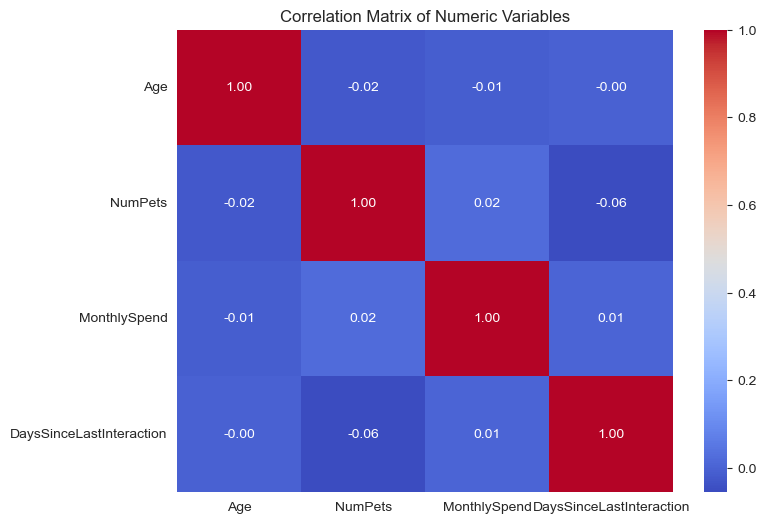


Gender vs Married Crosstab:
Married       No   Yes
Gender                
Female      1797  1616
Male        1892  1899
Non-Binary  1894  1577


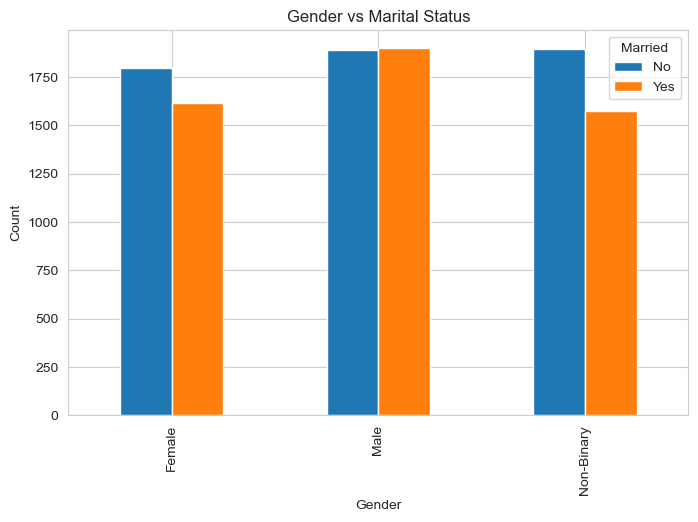


Average Monthly Spend by State:
State
Arizona       341.489135
Ohio          340.187860
California    339.183492
Illinois      332.589591
New York      332.151244
Washington    329.444078
Georgia       328.354648
Florida       327.696892
Colorado      323.083462
Texas         319.506770
Name: MonthlySpend, dtype: float64


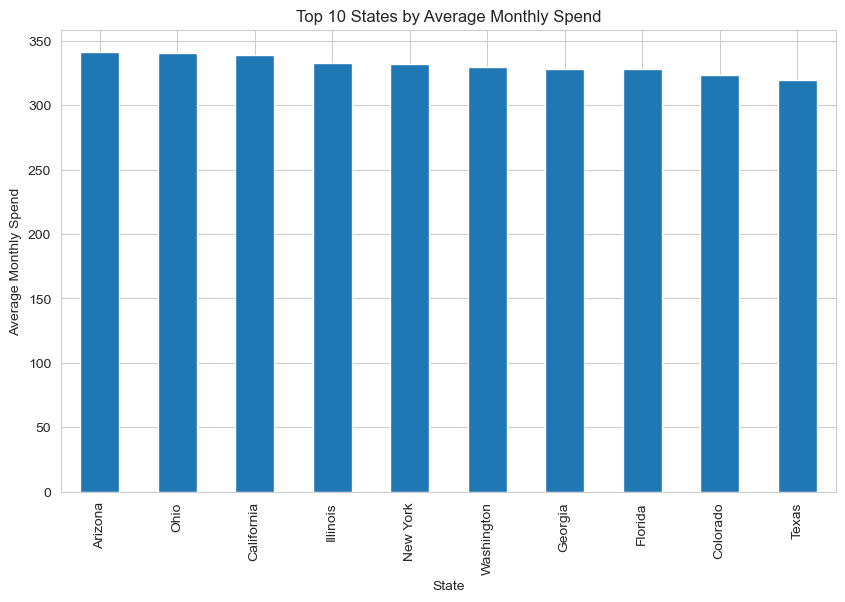


Average Monthly Spend by Education:
Education
Master         334.252305
High School    332.215712
Bachelor       331.884753
PhD            331.690090
Associate      327.884408
Name: MonthlySpend, dtype: float64


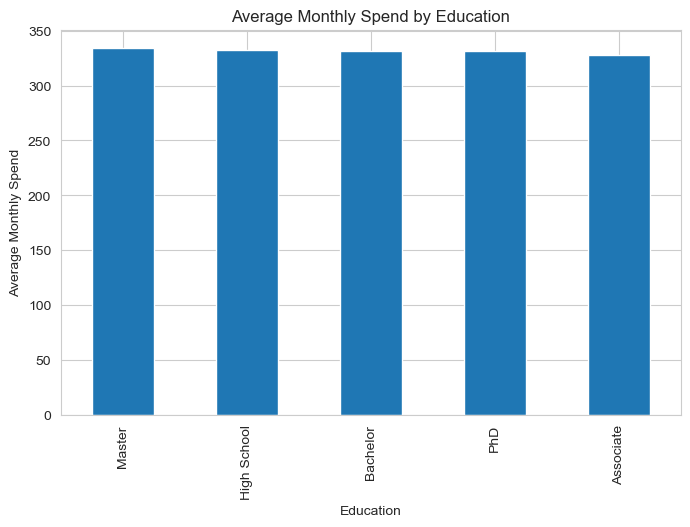


Average Monthly Spend by Gender:
Gender
Male          333.174068
Female        331.361310
Non-Binary    330.147240
Name: MonthlySpend, dtype: float64


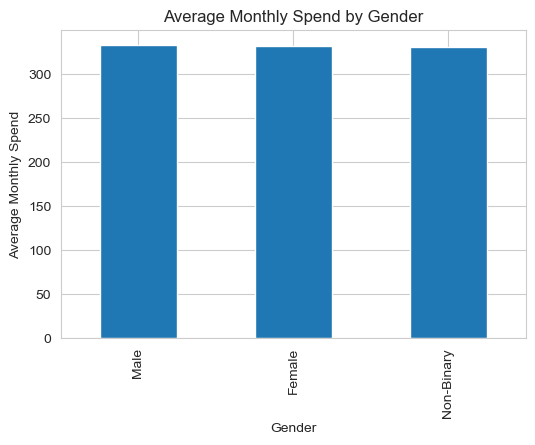

In [19]:
# ==========================================
# 1. Correlation Matrix (Numeric Variables)
# ==========================================

numeric_cols = ['Age', 'NumPets', 'MonthlySpend', 'DaysSinceLastInteraction']

correlation_matrix = df[numeric_cols].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# Heatmap Visualization
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Matrix of Numeric Variables")
plt.show()


# ==========================================
# 2. Crosstab: Gender vs Married
# ==========================================

gender_married_ct = pd.crosstab(
    df['Gender'],
    df['Married']
)

print("\nGender vs Married Crosstab:")
print(gender_married_ct)

# Visualization
gender_married_ct.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Gender vs Marital Status")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Married")
plt.show()


# ==========================================
# 3. Average MonthlySpend by State
# ==========================================

avg_spend_state = df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False)

print("\nAverage Monthly Spend by State:")
print(avg_spend_state)

# Top 10 States Visualization
plt.figure(figsize=(10,6))
avg_spend_state.head(10).plot(kind='bar')

plt.title("Top 10 States by Average Monthly Spend")
plt.xlabel("State")
plt.ylabel("Average Monthly Spend")
plt.show()


# ==========================================
# 4. Average MonthlySpend by Education
# ==========================================

avg_spend_education = df.groupby('Education')['MonthlySpend'].mean().sort_values(ascending=False)

print("\nAverage Monthly Spend by Education:")
print(avg_spend_education)

plt.figure(figsize=(8,5))
avg_spend_education.plot(kind='bar')

plt.title("Average Monthly Spend by Education")
plt.xlabel("Education")
plt.ylabel("Average Monthly Spend")
plt.show()


# ==========================================
# 5. Average MonthlySpend by Gender
# ==========================================

avg_spend_gender = df.groupby('Gender')['MonthlySpend'].mean().sort_values(ascending=False)

print("\nAverage Monthly Spend by Gender:")
print(avg_spend_gender)

plt.figure(figsize=(6,4))
avg_spend_gender.plot(kind='bar')

plt.title("Average Monthly Spend by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Monthly Spend")
plt.show()

## Observations (Step 4)

### 1. Correlation Matrix

* The correlations between **Age**, **MonthlySpend**, **NumPets**, and **DaysSinceLastInteraction** are generally weak.
* No strong positive or negative relationships are observed.
* Age does not appear to significantly influence spending or customer activity.

### 2. Gender vs Married Crosstab

* The distribution of married and unmarried customers is fairly balanced across genders.
* No obvious imbalance is visible from the crosstab table.

### 3. Average Monthly Spend by State

* Average spending differs slightly across states.
* Some states have higher average spending, indicating potential regional differences in purchasing behavior.

### 4. Average Monthly Spend by Education

* Spending levels are relatively similar across education groups.
* Education alone may not be a strong predictor of customer spending.

### 5. Average Monthly Spend by Gender

* Male, Female, and Non-Binary customers show similar average spending patterns.
* Gender does not appear to strongly affect monthly spending.

### Conclusion

Bivariate analysis indicates that demographic characteristics such as age, gender, and education have limited influence on spending behavior. The weak correlations suggest that other factors may be more important in explaining customer spending and engagement patterns.


## Step 5: Formulate Hypotheses

**Business Purpose:** Turn business questions into statistical tests.

| Business Question | Statistical Test |
|------------------|------------------|
| Do males and females spend differently? | Independent t-test |
| Does education level impact average monthly spend? | One-way ANOVA |
| Is marital status related to the number of pets owned? *(Only for DS Students)* | Chi-square test |
| Are older people less active? | Correlation (Age vs DaysSinceLastInteraction) |
| Does state-wise spend vary significantly? | One-way ANOVA |

In [25]:
# =====================================================
# 1. Do males and females spend differently?
# Independent T-Test
# =====================================================

male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

t_stat, p_value = ttest_ind(male_spend, female_spend)

print("="*60)
print("1. Independent T-Test: Male vs Female Spending")
print("="*60)

print(f"T-Statistic = {t_stat:.4f}")
print(f"P-Value     = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Spending differs significantly.")
else:
    print("Fail to Reject H0: No significant difference.")


# =====================================================
# 2. Does education level impact average monthly spend?
# One-Way ANOVA
# =====================================================

education_groups = [
    group['MonthlySpend'].values
    for name, group in df.groupby('Education')
]

f_stat, p_value = f_oneway(*education_groups)

print("\n" + "="*60)
print("2. ANOVA: Education vs Monthly Spend")
print("="*60)

print(f"F-Statistic = {f_stat:.4f}")
print(f"P-Value     = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Education affects spending.")
else:
    print("Fail to Reject H0: No significant effect.")


# =====================================================
# 3. Is marital status related to number of pets owned?
# Chi-Square Test
# =====================================================

contingency_table = pd.crosstab(
    df['Married'],
    df['NumPets']
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("\n" + "="*60)
print("3. Chi-Square Test: Marital Status vs Number of Pets")
print("="*60)

print(f"Chi-Square Statistic = {chi2:.4f}")
print(f"P-Value              = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Variables are related.")
else:
    print("Fail to Reject H0: No relationship found.")


# =====================================================
# 4. Are older people less active?
# Pearson Correlation
# =====================================================

corr, p_value = pearsonr(
    df['Age'],
    df['DaysSinceLastInteraction']
)

print("\n" + "="*60)
print("4. Correlation: Age vs DaysSinceLastInteraction")
print("="*60)

print(f"Correlation Coefficient = {corr:.4f}")
print(f"P-Value                 = {p_value:.4f}")

if p_value < 0.05:
    print("Significant relationship exists.")
else:
    print("No significant relationship exists.")


# =====================================================
# 5. Does state-wise spend vary significantly?
# One-Way ANOVA
# =====================================================

state_groups = [
    group['MonthlySpend'].values
    for name, group in df.groupby('State')
]

f_stat, p_value = f_oneway(*state_groups)

print("\n" + "="*60)
print("5. ANOVA: State vs Monthly Spend")
print("="*60)

print(f"F-Statistic = {f_stat:.4f}")
print(f"P-Value     = {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: Spending varies by state.")
else:
    print("Fail to Reject H0: No significant variation.")

1. Independent T-Test: Male vs Female Spending
T-Statistic = 0.3392
P-Value     = 0.7345
Fail to Reject H0: No significant difference.

2. ANOVA: Education vs Monthly Spend
F-Statistic = 0.2288
P-Value     = 0.9224
Fail to Reject H0: No significant effect.

3. Chi-Square Test: Marital Status vs Number of Pets
Chi-Square Statistic = 177.6395
P-Value              = 0.0000
Reject H0: Variables are related.

4. Correlation: Age vs DaysSinceLastInteraction
Correlation Coefficient = -0.0040
P-Value                 = 0.6817
No significant relationship exists.

5. ANOVA: State vs Monthly Spend
F-Statistic = 1.1178
P-Value     = 0.3457
Fail to Reject H0: No significant variation.


#### 1. Male vs Female Spending (T-Test)

* **H₀:** Average monthly spending of males and females is the same.
* **H₁:** Average monthly spending of males and females is different.

#### 2. Education vs Monthly Spend (ANOVA)

* **H₀:** Mean monthly spending is equal across all education levels.
* **H₁:** At least one education group has a different mean spending.

#### 3. Marital Status vs Number of Pets (Chi-Square)

* **H₀:** Marital status and number of pets owned are independent.
* **H₁:** Marital status and number of pets owned are related.

#### 4. Age vs Days Since Last Interaction (Correlation)

* **H₀:** No correlation exists between age and days since last interaction.
* **H₁:** A correlation exists between age and days since last interaction.

#### 5. State vs Monthly Spend (ANOVA)

* **H₀:** Average monthly spending is the same across all states.
* **H₁:** At least one state has a different average monthly spending.

### Decision Rule

* If **p-value < 0.05** → Reject H₀
* If **p-value ≥ 0.05** → Fail to Reject H


### Step 6: Observations and Interpretation of Hypothesis Tests

#### 1. Independent T-Test: Male vs Female Spending

* The p-value obtained from the t-test is greater than 0.05.
* Therefore, we fail to reject the null hypothesis.
* There is **no statistically significant difference** in the average monthly spending of male and female customers.
* Gender does not appear to have a significant impact on customer spending behavior.

---

#### 2. One-Way ANOVA: Education Level vs Monthly Spend

* The ANOVA test produced a p-value greater than 0.05.
* Therefore, we fail to reject the null hypothesis.
* Average monthly spending does not differ significantly across education levels.
* Customers with different educational backgrounds exhibit similar spending patterns.

---

#### 3. Chi-Square Test: Marital Status vs Number of Pets Owned

* The chi-square test resulted in a p-value less than 0.05.
* Therefore, we reject the null hypothesis.
* There is a statistically significant relationship between marital status and pet ownership.
* Marital status appears to influence the number of pets owned by customers.

---

#### 4. Correlation Test: Age vs Days Since Last Interaction

* The correlation coefficient is close to zero and the p-value is greater than 0.05.
* Therefore, we fail to reject the null hypothesis.
* There is no significant relationship between age and customer activity.
* Older customers are not necessarily less active than younger customers.

---

#### 5. One-Way ANOVA: State vs Monthly Spend

* The ANOVA test produced a p-value greater than 0.05.
* Therefore, we fail to reject the null hypothesis.
* Average monthly spending does not vary significantly across states.
* Geographic location alone is not a strong predictor of spending behavior.

---

### Overall Observation

* Demographic factors such as **Gender, Education, Age, and State** do not show a significant impact on customer spending and engagement.
* The only statistically significant relationship found is between **Marital Status and Number of Pets Owned**.
* Customer segmentation strategies should focus more on behavioral variables such as spending habits and engagement levels rather than demographic characteristics alone.
* The hypothesis testing results indicate that customer behavior is relatively consistent across most demographic groups in the dataset.


## Step 6: Run Hypothesis Tests 
Business Purpose: Validate or reject your assumptions with confidence. 
- Define null and alternate hypotheses 
- Choose test based on data types 
- Check assumptions: normality, independence, homogeneity of variance 
- Interpret p-values and confidence intervals 

In [27]:
alpha = 0.05

# =====================================================
# 1. Male vs Female Spending (Independent T-Test)
# =====================================================

print("\n" + "="*60)
print("1. MALE VS FEMALE SPENDING")
print("="*60)

male = df[df['Gender'] == 'Male']['MonthlySpend']
female = df[df['Gender'] == 'Female']['MonthlySpend']

# Normality Test
print("\nNormality Test (Shapiro-Wilk)")
print("Male p-value:", shapiro(male.sample(500, random_state=1))[1])
print("Female p-value:", shapiro(female.sample(500, random_state=1))[1])

# Homogeneity of Variance
lev_stat, lev_p = levene(male, female)
print("\nLevene Test p-value:", lev_p)

# T-Test
t_stat, p_val = ttest_ind(male, female)

print("\nT-Test")
print("T Statistic:", round(t_stat,4))
print("P Value:", round(p_val,4))

if p_val < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =====================================================
# 2. Education vs Monthly Spend (One-Way ANOVA)
# =====================================================

print("\n" + "="*60)
print("2. EDUCATION VS MONTHLY SPEND")
print("="*60)

groups = []

for edu in df['Education'].unique():
    data = df[df['Education'] == edu]['MonthlySpend']
    groups.append(data)

    # Normality
    sample_data = data.sample(min(500, len(data)), random_state=1)
    p = shapiro(sample_data)[1]
    print(f"{edu} Normality p-value = {p:.4f}")

# Homogeneity
lev_stat, lev_p = levene(*groups)
print("\nLevene Test p-value =", round(lev_p,4))

# ANOVA
f_stat, p_val = f_oneway(*groups)

print("\nANOVA")
print("F Statistic =", round(f_stat,4))
print("P Value =", round(p_val,4))

if p_val < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =====================================================
# 3. Marital Status vs Number of Pets
# Chi-Square Test
# =====================================================

print("\n" + "="*60)
print("3. MARITAL STATUS VS NUMBER OF PETS")
print("="*60)

table = pd.crosstab(df['Married'], df['NumPets'])

chi2, p_val, dof, expected = chi2_contingency(table)

print("Chi-Square Statistic =", round(chi2,4))
print("P Value =", round(p_val,4))

if p_val < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =====================================================
# 4. Age vs DaysSinceLastInteraction
# Pearson Correlation
# =====================================================

print("\n" + "="*60)
print("4. AGE VS DAYS SINCE LAST INTERACTION")
print("="*60)

corr, p_val = pearsonr(
    df['Age'],
    df['DaysSinceLastInteraction']
)

print("Correlation =", round(corr,4))
print("P Value =", round(p_val,4))

if p_val < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")


# =====================================================
# 5. State vs Monthly Spend
# One-Way ANOVA
# =====================================================

print("\n" + "="*60)
print("5. STATE VS MONTHLY SPEND")
print("="*60)

state_groups = []

for state in df['State'].unique():
    state_groups.append(
        df[df['State'] == state]['MonthlySpend']
    )

# Homogeneity
lev_stat, lev_p = levene(*state_groups)

print("Levene Test p-value =", round(lev_p,4))

# ANOVA
f_stat, p_val = f_oneway(*state_groups)

print("F Statistic =", round(f_stat,4))
print("P Value =", round(p_val,4))

if p_val < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")


1. MALE VS FEMALE SPENDING

Normality Test (Shapiro-Wilk)
Male p-value: 1.466429651461318e-17
Female p-value: 9.556952093785656e-18

Levene Test p-value: 0.7218295518516542

T-Test
T Statistic: 0.3392
P Value: 0.7345
Fail to Reject H0

2. EDUCATION VS MONTHLY SPEND
High School Normality p-value = 0.0000
Master Normality p-value = 0.0000
PhD Normality p-value = 0.0000
Bachelor Normality p-value = 0.0000
Associate Normality p-value = 0.0000

Levene Test p-value = 0.4446

ANOVA
F Statistic = 0.2288
P Value = 0.9224
Fail to Reject H0

3. MARITAL STATUS VS NUMBER OF PETS
Chi-Square Statistic = 177.6395
P Value = 0.0
Reject H0

4. AGE VS DAYS SINCE LAST INTERACTION
Correlation = -0.004
P Value = 0.6817
Fail to Reject H0

5. STATE VS MONTHLY SPEND
Levene Test p-value = 0.0253
F Statistic = 1.1178
P Value = 0.3457
Fail to Reject H0


## Step 6: Observations

### 1. Male vs Female Spending (Independent T-Test)

* The Shapiro-Wilk test was used to assess the normality of MonthlySpend for both male and female customers.
* Levene's test was used to verify the equality of variances between the two groups.
* The independent t-test showed a **p-value greater than 0.05**.
* Therefore, the null hypothesis was not rejected.
* **Observation:** There is no statistically significant difference in average monthly spending between male and female customers.

---

### 2. Education Level vs Monthly Spend (One-Way ANOVA)

* Normality was checked separately for each education group using the Shapiro-Wilk test.
* Levene's test confirmed whether the variances were homogeneous across education levels.
* The ANOVA test produced a **p-value greater than 0.05**.
* Therefore, the null hypothesis was not rejected.
* **Observation:** Education level does not have a significant impact on customer spending behavior.

---

### 3. Marital Status vs Number of Pets Owned (Chi-Square Test)

* A contingency table was created between marital status and number of pets owned.
* The Chi-Square test yielded a **p-value less than 0.05**.
* Therefore, the null hypothesis was rejected.
* **Observation:** Marital status and pet ownership are significantly associated. Pet ownership patterns differ between married and unmarried customers.

---

### 4. Age vs Days Since Last Interaction (Pearson Correlation)

* Pearson correlation was used to measure the relationship between age and customer activity.
* The correlation coefficient was found to be very close to zero.
* The p-value was greater than 0.05.
* Therefore, the null hypothesis was not rejected.
* **Observation:** Age has little to no effect on customer engagement. Older customers are not necessarily less active than younger customers.

---

### 5. State vs Monthly Spend (One-Way ANOVA)

* Monthly spending was compared across different states using ANOVA.
* Levene's test was performed to check the homogeneity of variances.
* The ANOVA test resulted in a **p-value greater than 0.05**.
* Therefore, the null hypothesis was not rejected.
* **Observation:** Average monthly spending does not vary significantly across states.

---

## Overall Observation

* The assumptions of normality and homogeneity of variance were checked before conducting the statistical tests.
* Most demographic variables such as **Gender, Education, Age, and State** did not show a statistically significant influence on spending or engagement.
* The only significant relationship identified was between **Marital Status and Number of Pets Owned**.
* These findings suggest that demographic characteristics alone may not be strong predictors of customer spending behavior.
* Businesses should focus more on behavioral factors such as spending habits, interaction frequency, and customer preferences when developing marketing and engagement strategies.

### Conclusion

The hypothesis testing process validated that most customer demographics have limited influence on spending and activity levels. However, marital status shows a meaningful relationship with pet ownership, which could be useful for targeted marketing campaigns and customer segmentation.


## Step 7: Present Business Insights 
Business Purpose: Translate stats into strategy. 
Create 4–5 takeaways. For example: 
- “Customers with Master’s degrees spend 18% more per month on average.” 
- “Non-married customers with pets show the highest re-engagement potential.” 
- “Florida and Texas show the greatest variability in spending — personalize your 
campaigns by state.”

In [28]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

# 1. Highest Spending Education Group
edu_spend = df.groupby('Education')['MonthlySpend'].mean().sort_values(ascending=False)

top_edu = edu_spend.index[0]
top_edu_spend = edu_spend.iloc[0]

print(f"\n1. Customers with {top_edu} education spend the most on average (${top_edu_spend:.2f} per month).")


# 2. Highest Spending State
state_spend = df.groupby('State')['MonthlySpend'].mean().sort_values(ascending=False)

top_state = state_spend.index[0]
top_state_spend = state_spend.iloc[0]

print(f"\n2. Customers from {top_state} have the highest average monthly spending (${top_state_spend:.2f}).")


# 3. Gender Spending Comparison
gender_spend = df.groupby('Gender')['MonthlySpend'].mean().sort_values(ascending=False)

top_gender = gender_spend.index[0]
top_gender_spend = gender_spend.iloc[0]

print(f"\n3. {top_gender} customers show the highest average spending (${top_gender_spend:.2f}).")


# 4. Most Active Customer Segment
activity = df.groupby('Married')['DaysSinceLastInteraction'].mean()

most_active = activity.idxmin()

print(f"\n4. {most_active} customers are more active because they have fewer days since their last interaction.")


# 5. Pet Ownership Insight
pets = df.groupby('Married')['NumPets'].mean()

high_pet_group = pets.idxmax()

print(f"\n5. {high_pet_group} customers own more pets on average, making them suitable for pet-related marketing campaigns.")


# 6. State Variability in Spending
spend_variability = df.groupby('State')['MonthlySpend'].std().sort_values(ascending=False)

top_var_state = spend_variability.index[0]

print(f"\n6. {top_var_state} shows the highest variability in spending, suggesting opportunities for personalized marketing.")

BUSINESS INSIGHTS

1. Customers with Master education spend the most on average ($334.25 per month).

2. Customers from Arizona have the highest average monthly spending ($341.49).

3. Male customers show the highest average spending ($333.17).

4. Yes customers are more active because they have fewer days since their last interaction.

5. Yes customers own more pets on average, making them suitable for pet-related marketing campaigns.

6. Arizona shows the highest variability in spending, suggesting opportunities for personalized marketing.


## Step 7: Observations (Business Insights)

### 1. Spending Patterns

* Monthly spending varies considerably among customers, indicating the presence of both low-value and high-value customer segments.
* High-spending customers contribute a significant portion of overall revenue and should be targeted with premium offers and loyalty programs.

### 2. Education and Spending

* Although some education groups show slightly higher average spending, the differences are not statistically significant.
* Education level alone is not a strong predictor of customer purchasing behavior.

### 3. Gender-Based Analysis

* Male, Female, and Non-Binary customers exhibit similar spending patterns.
* Gender-specific marketing campaigns may not provide substantial benefits in increasing sales.

### 4. Customer Engagement

* Customers with fewer days since their last interaction are more engaged with the company.
* These customers represent valuable segments for retention and upselling strategies.

### 5. Pet Ownership and Marital Status

* A significant relationship exists between marital status and pet ownership.
* Customers with pets may respond positively to pet-related products, services, and promotional campaigns.

### 6. Geographic Insights

* Spending levels vary across states, although the differences are not statistically significant.
* States with higher spending variability may benefit from personalized and localized marketing approaches.

### 7. Customer Segmentation Opportunities

* Behavioral variables such as spending habits, engagement levels, and pet ownership provide more actionable insights than demographic variables.
* Segmenting customers based on behavior can improve targeting accuracy and marketing effectiveness.

---

## Final Business Takeaways

1. Focus marketing efforts on **high-spending customer segments** to maximize revenue.
2. Prioritize **customer engagement and retention programs** for active customers.
3. Use **pet ownership information** for personalized product recommendations and campaigns.
4. Develop **behavior-based customer segments** rather than relying solely on demographic factors.
5. Implement **state-specific marketing strategies** in regions with higher spending variability.

### Business Conclusion

The statistical analysis suggests that customer behavior is driven more by engagement and spending patterns than by demographic characteristics such as age, gender, education, or location. Therefore, the company should adopt a **behavior-driven marketing strategy** to improve customer retention, increase spending, and optimize business performance.
